# Egypt real estate prices: the numbers

Every number in the README, on the two SVG pictures, on the project card and in the Power BI checks
comes from this notebook. It reads the warehouse after a weekly run: start the stack
(`docker compose up -d`), let the `egypt_real_estate_prices` DAG finish, then run this notebook top
to bottom. Each measure lands in `numbers`; the last cells write `analysis/numbers.json` and then
fill the README and the SVGs from that file, so no number is typed by hand.

Each section states its grain: what one row of its table is.

In [1]:
import json
import os
import re
import warnings
from datetime import date
from decimal import ROUND_HALF_UP, Decimal
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import psycopg

# requests warns at import when urllib3 or chardet is newer than it knows; the notice names a local path.
warnings.filterwarnings("ignore", message=r"urllib3 .* doesn't match a supported version")
import requests  # noqa: E402

ROOT = Path.cwd().parent if Path.cwd().name == "analysis" else Path.cwd()
for line in (ROOT / ".env").read_text().splitlines():  # the warehouse password
    if "=" in line and not line.startswith("#"):
        key, value = line.split("=", 1)
        os.environ.setdefault(key, value)

conn = psycopg.connect(host="127.0.0.1", port=5451, dbname="prices", user="prices",
                       password=os.environ["WAREHOUSE_PASSWORD"])


def query(sql, *params):
    with conn.cursor() as cur:
        cur.execute(sql, params)
        rows = [[float(v) if isinstance(v, Decimal) else v for v in row] for row in cur.fetchall()]
        return pd.DataFrame(rows, columns=[c.name for c in cur.description])


def half_up(value, places):
    """Round half away from zero, as the slots are written (Python's round() rounds half to even)."""
    return Decimal(str(value)).quantize(Decimal(1).scaleb(-places), rounding=ROUND_HALF_UP)


def pct(value, signed=False):
    return f"{half_up(value, 1):{'+' if signed else ''}}"


numbers = {}  # every measure lands here; numbers.json is written from it at the end

# The README and SVG slot names for each area (docs/notebook-slots.md).
AREA_SLOT = {"new-cairo": "new_cairo", "new-administrative-capital": "new_capital",
             "sheikh-zayed": "sheikh_zayed", "sixth-october-city": "sixth_october",
             "north-coast": "north_coast", "mostakbal-city": "mostakbal_city"}

# Dark charts to sit beside the dark SVGs. Site colours: the dataviz skill's dark categorical
# slots 1 to 6 in fixed order, validated on this surface; amber is kept for our units only.
SURFACE, INK, MUTED, GRID, AMBER = "#0B1220", "#E2E8F0", "#94A3B8", "#334155", "#F59E0B"
SITE_COLOURS = ["#3987e5", "#d95926", "#199e70", "#c98500", "#d55181", "#008300"]
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "text.color": INK, "axes.labelcolor": MUTED, "xtick.color": MUTED, "ytick.color": INK,
    "axes.edgecolor": GRID, "axes.spines.top": False, "axes.spines.right": False,
    "axes.titleweight": "bold", "axes.titlesize": 14, "axes.titlelocation": "left", "axes.titlecolor": INK,
    "font.family": "sans-serif", "font.sans-serif": ["Segoe UI", "Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 11, "figure.dpi": 110, "savefig.bbox": "tight", "savefig.pad_inches": 0.3,
})

## 1. The run week and its rows

Grain: one row of `gold.fact_listing_price` is one site, listing and run week. The latest run week
is the newest week in `gold.dim_week`. The loader's counts must reconcile three ways before anything
else is measured: the fact rows of the week, the week's rows in `silver.price_observation`, and the
saved rows in `silver.run_log` (one row per site, area asked and run week). An empty or partial
week stops the notebook here.

In [2]:
latest_week = query("SELECT max(week_key) AS week FROM gold.dim_week").week[0]
assert latest_week is not None, "gold.dim_week is empty: no run has been built"

history = query("SELECT count(*) AS prices, count(DISTINCT run_week) AS weeks, min(run_week) AS first_week,"
                " max(run_week) AS last_week FROM silver.price_observation").iloc[0]
week = query("SELECT count(*) AS listings, count(DISTINCT site_key) AS sites, count(DISTINCT area_key) AS areas"
             " FROM gold.fact_listing_price WHERE week_key = %s", latest_week).iloc[0]
week_prices = query("SELECT count(*) AS n FROM silver.price_observation WHERE run_week = %s", latest_week).n[0]
run_log = query("SELECT * FROM silver.run_log WHERE run_week = %s", latest_week)

assert week.listings > 0, f"no listing in gold for {latest_week}: the run loaded nothing"
assert history.last_week == latest_week, "silver and gold disagree on the latest run week"
assert week.listings == week_prices == run_log.rows_saved.sum(), (week.listings, week_prices, run_log.rows_saved.sum())
assert (run_log.rows_parsed == run_log.rows_skipped + run_log.rows_duplicate + run_log.rows_saved
        + run_log.rows_quarantined).all(), "a run_log row does not reconcile"

numbers.update(
    latest_run_week=latest_week.isoformat(), first_run_week=history.first_week.isoformat(),
    run_weeks=int(history.weeks), price_observations=int(history.prices),
    listings_compared=int(week.listings), sites_read=int(week.sites), areas_read=int(week.areas),
    rows_parsed=int(run_log.rows_parsed.sum()), rows_skipped=int(run_log.rows_skipped.sum()),
    rows_duplicate=int(run_log.rows_duplicate.sum()), rows_saved=int(run_log.rows_saved.sum()),
)
numbers["run_weeks_phrase"] = f"{numbers['run_weeks']:,} weekly run{'' if numbers['run_weeks'] == 1 else 's'}"
print(f"Run week {latest_week}: {week.listings:,} listings from {week.sites} sites in {week.areas} areas; "
      f"{history.prices:,} asking prices kept over {history.weeks} run week(s)")
print(f"run_log: {numbers['rows_parsed']:,} rows parsed = {numbers['rows_skipped']:,} skipped + "
      f"{numbers['rows_duplicate']:,} duplicates + {numbers['rows_saved']:,} saved + "
      f"{int(run_log.rows_quarantined.sum()):,} quarantined")

Run week 2026-10-04: 5,782 listings from 6 sites in 6 areas; 5,782 asking prices kept over 1 run week(s)
run_log: 6,988 rows parsed = 960 skipped + 220 duplicates + 5,782 saved + 26 quarantined


## 2. Listings per site and area

Grain: one cell is one site and one area, latest run week, counted in `gold.fact_listing_price`.
The area is the listing's own area, which can differ from the area its search asked for
(section 3 counts by the area asked, so the two tables differ cell by cell and agree in total).

In [3]:
sites = query("SELECT site_key, source, name FROM gold.dim_site ORDER BY site_key")
areas = query("SELECT area_id, name FROM gold.dim_area ORDER BY area_key")
listings = query("""
    SELECT s.source, a.area_id, count(*) AS listings
    FROM gold.fact_listing_price f JOIN gold.dim_site s USING (site_key) JOIN gold.dim_area a USING (area_key)
    WHERE f.week_key = %s GROUP BY 1, 2
""", latest_week)
grid = listings.pivot_table(index="area_id", columns="source", values="listings", aggfunc="sum", fill_value=0)
grid = grid.reindex(index=areas.area_id, columns=sites.source, fill_value=0)
assert grid.values.sum() == numbers["listings_compared"]

numbers["listings_by_site"] = {s: int(n) for s, n in grid.sum().items()}
numbers["listings_by_area"] = {AREA_SLOT[a]: int(n) for a, n in grid.sum(axis=1).items()}
numbers["listings_by_site_and_area"] = {s: {AREA_SLOT[a]: int(grid.at[a, s]) for a in grid.index} for s in grid.columns}
shown = grid.rename(index=dict(zip(areas.area_id, areas.name)), columns=dict(zip(sites.source, sites.name)))
shown.loc["All areas"] = shown.sum()
shown.assign(**{"All sites": shown.sum(axis=1)})

source,realestate.eg,Property Finder Egypt,Dubizzle Egypt,Nawy,Bayut Egypt,Aqarmap,All sites
area_id,,,,,,,
New Cairo,151,179,359,127,24,101,941
New Capital,101,159,360,118,24,115,877
Sheikh Zayed,168,160,354,141,24,122,969
6th of October,154,161,360,157,24,126,982
North Coast,184,156,359,163,23,145,1030
Mostakbal City,178,159,360,152,24,110,983
All areas,936,974,2152,858,143,719,5782


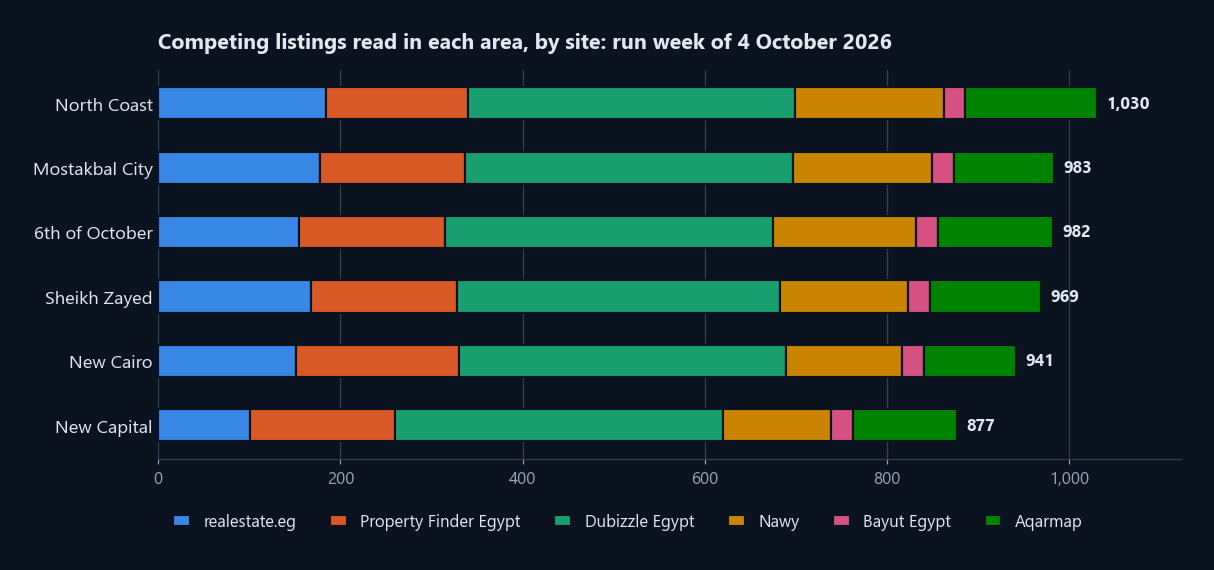

In [4]:
area_name = dict(zip(areas.area_id, areas.name))
order = grid.sum(axis=1).sort_values().index  # the largest area on top
fig, ax = plt.subplots(figsize=(12, 4.6))
left = pd.Series(0, index=order)
for colour, source, name in zip(SITE_COLOURS, sites.source, sites.name):
    ax.barh([area_name[a] for a in order], grid.loc[order, source], left=left, height=0.5, color=colour,
            edgecolor=SURFACE, linewidth=1.4, label=name)
    left += grid.loc[order, source]
for y, total in enumerate(left):
    ax.text(total + left.max() * 0.01, y, f"{total:,}", va="center", color=INK, fontweight="bold")
ax.set_xlim(0, left.max() * 1.09)
ax.xaxis.set_major_formatter(lambda x, _: f"{x:,.0f}")
ax.xaxis.grid(True, color=GRID, linewidth=0.8)
ax.set_axisbelow(True)
ax.spines["left"].set_visible(False)
ax.tick_params(axis="y", length=0, labelsize=12)
ax.set_title(f"Competing listings read in each area, by site: run week of {latest_week.day} {latest_week:%B %Y}", pad=14)
ax.legend(ncol=6, frameon=False, loc="upper left", bbox_to_anchor=(0, -0.1), handlelength=1, labelcolor=INK)
fig.savefig(ROOT / "docs" / "listings-by-area.png")

## 3. Coverage: listings read against each site's own count

Grain: one row is one site, one area asked and one run week (`silver.run_log`). `stated_total` is
the number of results the site's own search page says it holds; `rows_parsed` is the listings the
run read from the pages it opened; `rows_saved` is what reached silver after the checks
(residential, inside our six areas, not a duplicate, not quarantined). Coverage is `rows_parsed`
against `stated_total`. Each site counts its own way (some count every property type, some count
projects rather than units), so the percentages compare a site with itself, not sites with each other.

In [5]:
coverage = query("""
    SELECT s.name AS site, r.source, a.name AS area, r.stated_total, r.pages_read, r.rows_parsed, r.rows_saved
    FROM silver.run_log r JOIN gold.dim_site s USING (source) JOIN silver.area a USING (area_id)
    WHERE r.run_week = %s ORDER BY s.site_key, a.area_id
""", latest_week)
print(f"{coverage.stated_total.isna().sum()} of {len(coverage)} site and area searches gave no stated count")
coverage["read_pct"] = (coverage.rows_parsed / coverage.stated_total * 100).round(2)

by_site = coverage.groupby(["source", "site"], sort=False)[["stated_total", "rows_parsed", "rows_saved"]].sum()
by_site["read_pct"] = (by_site.rows_parsed / by_site.stated_total * 100).round(2)
numbers["coverage_by_site"] = {source: {"stated_total": int(r.stated_total), "rows_parsed": int(r.rows_parsed),
                                        "rows_saved": int(r.rows_saved), "read_pct": float(r.read_pct)}
                               for (source, _), r in by_site.iterrows()}
display(by_site)
coverage

0 of 36 site and area searches gave no stated count


,,stated_total,rows_parsed,rows_saved,read_pct
source,site,,,,
realestate,realestate.eg,13242,1650,936,12.46
propertyfinder,Property Finder Egypt,124083,983,974,0.79
dubizzle,Dubizzle Egypt,120186,2160,2152,1.80
nawy,Nawy,18636,1104,858,5.92
bayut,Bayut Egypt,123108,144,143,0.12
aqarmap,Aqarmap,748210,947,719,0.13


,site,source,area,stated_total,pages_read,rows_parsed,rows_saved,read_pct
0,realestate.eg,realestate,Mostakbal City,630,182,200,178,31.75
1,realestate.eg,realestate,New Capital,3644,109,400,101,10.98
2,realestate.eg,realestate,New Cairo,5456,158,350,151,6.41
3,realestate.eg,realestate,North Coast,1097,188,200,184,18.23
4,realestate.eg,realestate,Sheikh Zayed,1240,172,200,168,16.13
5,realestate.eg,realestate,6th of October,1175,160,300,154,25.53
6,Property Finder Egypt,propertyfinder,Mostakbal City,6555,8,161,159,2.46
7,Property Finder Egypt,propertyfinder,New Capital,4535,8,161,159,3.55
8,Property Finder Egypt,propertyfinder,New Cairo,49515,9,180,179,0.36
9,Property Finder Egypt,propertyfinder,North Coast,27450,8,160,156,0.58


## 4. Price per m² in each area

Grain: one row is one area, latest run week, pooled over the six sites and over every residential
unit type: the median asking price per m² and the middle half of the listings (25th to 75th
percentile), `percentile_cont` over `gold.fact_listing_price`. These are measured market numbers.
The second table is `gold.area_benchmark` (one row per area and unit type), the medians our units
are compared with in section 5.

In [6]:
market = query("""
    SELECT a.area_id, a.name AS area, count(*) AS listings,
           round(percentile_cont(0.25) WITHIN GROUP (ORDER BY f.price_per_m2)::numeric, 2) AS p25_m2,
           round(percentile_cont(0.5) WITHIN GROUP (ORDER BY f.price_per_m2)::numeric, 2) AS median_m2,
           round(percentile_cont(0.75) WITHIN GROUP (ORDER BY f.price_per_m2)::numeric, 2) AS p75_m2
    FROM gold.fact_listing_price f JOIN gold.dim_area a USING (area_key)
    WHERE f.week_key = %s GROUP BY 1, 2 ORDER BY median_m2 DESC
""", latest_week)
for r in market.itertuples():
    numbers[f"median_m2_{AREA_SLOT[r.area_id]}"] = r.median_m2
    numbers[f"p25_m2_{AREA_SLOT[r.area_id]}"] = r.p25_m2
    numbers[f"p75_m2_{AREA_SLOT[r.area_id]}"] = r.p75_m2
display(market)
query("""
    SELECT a.name AS area, t.unit_type, b.listings, b.median_price_per_m2, b.p25_price_per_m2, b.p75_price_per_m2
    FROM gold.area_benchmark b JOIN gold.dim_area a USING (area_key) JOIN gold.dim_property_type t USING (type_key)
    ORDER BY a.name, t.unit_type
""")

,area_id,area,listings,p25_m2,median_m2,p75_m2
0,north-coast,North Coast,1030,70000.00,114285.71,158232.05
1,new-cairo,New Cairo,941,54385.96,75842.70,104597.70
2,sheikh-zayed,Sheikh Zayed,969,41420.45,61926.61,92658.16
3,sixth-october-city,6th of October,982,40199.88,57849.11,85714.29
4,mostakbal-city,Mostakbal City,983,40038.46,55859.38,74165.16
5,new-administrative-capital,New Capital,877,34841.10,53000.00,82157.26


,area,unit_type,listings,median_price_per_m2,p25_price_per_m2,p75_price_per_m2
0,6th of October,Apartment,408,54343.68,32258.06,87871.38
1,6th of October,Chalet,2,22884.62,22019.23,23750.00
2,6th of October,Duplex,29,62136.00,50000.00,87500.00
3,6th of October,iVilla,43,41015.63,37831.17,51165.90
4,6th of October,Loft,2,114545.66,112932.12,116159.19
5,6th of October,Penthouse,65,49046.28,44237.41,65868.26
6,6th of October,Studio,47,76403.51,52155.54,93826.19
7,6th of October,Town House,124,64651.16,52728.84,86056.55
8,6th of October,Twin House,67,66000.00,54396.14,85414.98
9,6th of October,Villa,195,65000.00,43016.84,88444.45


## Our units are generated

The client is not named, so its units are made up: `make_units.py` puts ten units in each area,
inside real compounds seen on the sites, and prices each at a seeded random 15% below to 15% above
the market median of its type in its area. **The gap numbers below (sections 5, 6 and 8) therefore
show the method, not a finding about a real seller.** The market numbers (listings, medians,
coverage, compounds, developers, quarantine) are measured from the sites.

## 5. Our units against the area median of their type

Grain of the first table: one row per unit of ours (`gold.unit_gap`): its price per m² against the
pooled median of the same unit type in the same area, latest run week; `gap_pct` is signed, + when
we ask more. Grain of the second: one row per area (`gold.area_gap`): the median of its units' gaps,
and `gap_rank` 1 for the widest gap in absolute terms. The median gap is recomputed here from the
unit rows and must match the view.

In [7]:
units = query("""
    SELECT g.unit_code, a.area_id, a.name AS area, t.unit_type, g.price_per_m2, g.median_price_per_m2,
           g.gap_pct, g.listings_compared, g.listings_cheaper
    FROM gold.unit_gap g JOIN gold.dim_area a USING (area_key) JOIN gold.dim_property_type t USING (type_key)
    ORDER BY a.name, g.unit_code
""")
our_units = query("SELECT count(*) AS n FROM gold.fact_our_unit").n[0]
area_gap = query("""
    SELECT a.area_id, a.name AS area, g.units, g.units_compared, g.median_gap_pct, g.pct_listings_cheaper, g.gap_rank
    FROM gold.area_gap g JOIN gold.dim_area a USING (area_key) ORDER BY g.gap_rank, a.name
""")
assert len(units) == our_units > 0
recomputed = units.groupby("area_id").gap_pct.median().reindex(area_gap.area_id)
assert ((recomputed.values - area_gap.median_gap_pct.values).__abs__() < 0.006).all(), "median gap differs from gold.area_gap"

numbers.update(our_units=int(our_units), units_without_comparison=int(units.gap_pct.isna().sum()),
               units_above_market=int((units.gap_pct > 0).sum()))
for r in area_gap.itertuples():
    numbers[f"gap_pct_{AREA_SLOT[r.area_id]}"] = r.median_gap_pct
    numbers[f"our_units_m2_{AREA_SLOT[r.area_id]}"] = sorted(units.loc[units.area_id == r.area_id, "price_per_m2"])
print(f"{our_units} units of ours, {numbers['units_without_comparison']} without a comparison, "
      f"{numbers['units_above_market']} asking more than the median of their type and area")
display(area_gap)
units

60 units of ours, 0 without a comparison, 35 asking more than the median of their type and area


,area_id,area,units,units_compared,median_gap_pct,pct_listings_cheaper,gap_rank
0,sixth-october-city,6th of October,10,10,7.39,51.35,1
1,sheikh-zayed,Sheikh Zayed,10,10,2.81,49.86,2
2,new-administrative-capital,New Capital,10,10,1.80,48.85,3
3,new-cairo,New Cairo,10,10,-0.74,53.52,4
4,mostakbal-city,Mostakbal City,10,10,-0.62,48.36,5
5,north-coast,North Coast,10,10,-0.05,48.16,6


,unit_code,area_id,area,unit_type,price_per_m2,median_price_per_m2,gap_pct,listings_compared,listings_cheaper
0,OCT-APT-01,sixth-october-city,6th of October,Apartment,49515.15,54343.68,-8.89,408,181
1,OCT-APT-02,sixth-october-city,6th of October,Apartment,46700.00,54343.68,-14.07,408,166
2,OCT-APT-03,sixth-october-city,6th of October,Apartment,59294.12,54343.68,9.11,408,239
3,OCT-APT-04,sixth-october-city,6th of October,Apartment,61225.81,54343.68,12.66,408,247
4,OCT-APT-05,sixth-october-city,6th of October,Apartment,53828.57,54343.68,-0.95,408,202
5,OCT-DUP-01,sixth-october-city,6th of October,Duplex,69888.89,62136.00,12.48,29,20
6,OCT-PH-01,sixth-october-city,6th of October,Penthouse,53555.56,49046.28,9.19,65,37
7,OCT-PH-02,sixth-october-city,6th of October,Penthouse,53935.48,49046.28,9.97,65,38
8,OCT-TH-01,sixth-october-city,6th of October,Town House,68320.00,64651.16,5.67,124,66
9,OCT-VIL-01,sixth-october-city,6th of October,Villa,64083.33,65000.00,-1.41,195,97


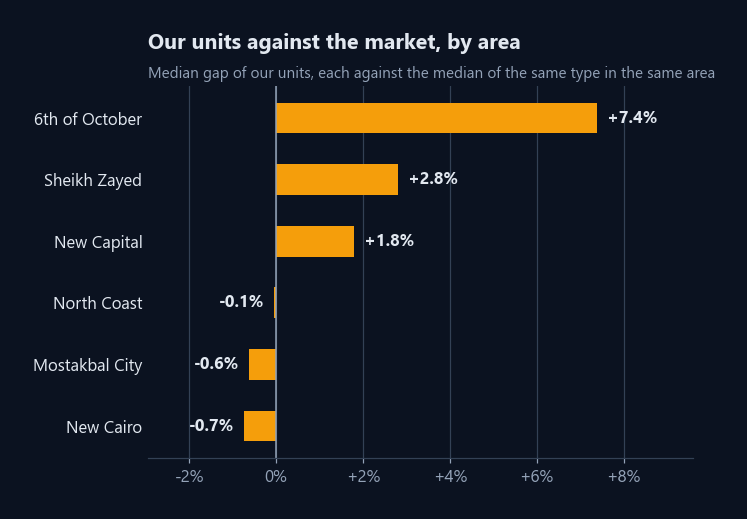

In [8]:
g = area_gap.sort_values("median_gap_pct")
fig, ax = plt.subplots(figsize=(6.4, 4.4))
ax.barh(g.area, g.median_gap_pct, height=0.5, color=AMBER)
ax.axvline(0, color=MUTED, linewidth=1)
span = g.median_gap_pct.abs().max()
for y, v in enumerate(g.median_gap_pct):
    ax.text(v + (span * 0.03 if v >= 0 else -span * 0.03), y, f"{pct(v, signed=True)}%", va="center",
            ha="left" if v >= 0 else "right", color=INK, fontweight="bold")
ax.set_xlim(min(0, g.median_gap_pct.min()) - span * 0.3, max(0, g.median_gap_pct.max()) + span * 0.3)
ax.xaxis.set_major_formatter(lambda x, _: f"{x:+.0f}%" if x else "0%")
ax.xaxis.grid(True, color=GRID, linewidth=0.8)
ax.set_axisbelow(True)
ax.spines["left"].set_visible(False)
ax.tick_params(axis="y", length=0)
ax.set_title("Our units against the market, by area", pad=24)
ax.text(0, 1.02, "Median gap of our units, each against the median of the same type in the same area", transform=ax.transAxes,
        color=MUTED, fontsize=10)
fig.savefig(ROOT / "docs" / "gap-by-area.png")

The picture `docs/price-gap-by-area.svg` puts every area on one price-per-m² scale. Its ends are
the lowest 25th percentile or unit price and the highest 75th percentile or unit price over all
areas, widened to the next 10,000 EGP. The band and the tick there are the pooled market of
section 4 (every type together), the dots are our units at their own price per m², and the gap
written beside each strip is the type-matched median gap above, so a dot can sit left of the tick
and still ask more than the median of its own type.

In [9]:
STEP = 10_000
low = min(market.p25_m2.min(), units.price_per_m2.min())
high = max(market.p75_m2.max(), units.price_per_m2.max())
numbers["scale_min_m2"] = int(low // STEP * STEP)
numbers["scale_max_m2"] = int(-(-high // STEP) * STEP)
print(f"Scale {numbers['scale_min_m2']:,} to {numbers['scale_max_m2']:,} EGP per m²")

Scale 30,000 to 170,000 EGP per m²


## 6. Competing listings cheaper per m² than ours

Grain: one row per competing listing of the latest run week in an area and unit type where we have
at least one unit; listings of a type we do not sell in that area are left out of the denominator.
A listing counts as cheaper when its price per m² is below that of our median unit of the same type
in the same area (the definition in `docs/notebook-slots.md`). `gold.area_gap.pct_listings_cheaper`
counts differently (every unit against every listing of its type, summed), so it is kept beside it
under its own name; the Power BI measure and check C3 use the definition above.

In [10]:
ours_median = units.groupby(["area_id", "unit_type"], as_index=False).price_per_m2.median()
ours_median = ours_median.rename(columns={"price_per_m2": "our_median_m2"})
competing = query("""
    SELECT a.area_id, t.unit_type, f.price_per_m2
    FROM gold.fact_listing_price f JOIN gold.dim_area a USING (area_key) JOIN gold.dim_property_type t USING (type_key)
    WHERE f.week_key = %s
""", latest_week)
compared = competing.merge(ours_median, on=["area_id", "unit_type"])  # only the types we sell in each area
compared["cheaper"] = compared.price_per_m2 < compared.our_median_m2

by_area = compared.groupby("area_id").cheaper.agg(listings="size", cheaper="sum")
by_area["cheaper_pct"] = by_area.cheaper / by_area.listings * 100
by_type = compared.groupby("unit_type").cheaper.agg(listings="size", cheaper="sum")
by_type["cheaper_pct"] = by_type.cheaper / by_type.listings * 100

numbers.update(listings_in_our_types=int(len(compared)), listings_cheaper_than_ours=int(compared.cheaper.sum()),
               share_listings_cheaper_than_ours=compared.cheaper.mean() * 100)
for area_id, r in by_area.iterrows():
    numbers[f"share_cheaper_{AREA_SLOT[area_id]}"] = r.cheaper_pct
numbers["share_cheaper_by_type"] = by_type.cheaper_pct.to_dict()
numbers["gold_area_gap_pct_listings_cheaper"] = {AREA_SLOT[r.area_id]: r.pct_listings_cheaper for r in area_gap.itertuples()}
print(f"{numbers['listings_cheaper_than_ours']:,} of {numbers['listings_in_our_types']:,} competing listings "
      f"({pct(numbers['share_listings_cheaper_than_ours'])}%) ask less per m² than our median unit of their type and area")
display(by_area.rename(index=area_name))
by_type

2,580 of 5,087 competing listings (50.7%) ask less per m² than our median unit of their type and area


,listings,cheaper,cheaper_pct
area_id,,,
Mostakbal City,945,449,47.513228
New Capital,838,445,53.102625
New Cairo,877,456,51.995439
North Coast,721,360,49.930652
Sheikh Zayed,885,448,50.621469
6th of October,821,422,51.400731


,listings,cheaper,cheaper_pct
unit_type,,,
Apartment,2110,1027,48.672986
Chalet,472,231,48.940678
Duplex,196,98,50.000000
Penthouse,172,100,58.139535
Town House,559,289,51.699463
Twin House,291,146,50.171821
Villa,1287,689,53.535354


## 7. Compounds and developers covered

Grain: one row of `gold.dim_compound` is one area, compound and developer as the sites write them,
`Unknown` when a site names none. Covered means named (not `Unknown`) and with at least one listing
in `gold.fact_listing_price`; a compound name is counted once even when it appears in two areas. The
listings without a compound or a developer are counted for the latest run week.

In [11]:
covered = query("""
    SELECT count(DISTINCT c.compound) FILTER (WHERE c.compound <> 'Unknown') AS compounds,
           count(DISTINCT c.developer) FILTER (WHERE c.developer <> 'Unknown') AS developers,
           count(DISTINCT (c.area_id, c.compound)) FILTER (WHERE c.compound <> 'Unknown') AS area_compounds
    FROM gold.dim_compound c WHERE EXISTS (SELECT 1 FROM gold.fact_listing_price f WHERE f.compound_key = c.compound_key)
""").iloc[0]
named = query("""
    SELECT count(*) AS listings, count(*) FILTER (WHERE c.compound = 'Unknown') AS without_compound,
           count(*) FILTER (WHERE c.developer = 'Unknown') AS without_developer
    FROM gold.fact_listing_price f JOIN gold.dim_compound c USING (compound_key) WHERE f.week_key = %s
""", latest_week).iloc[0]
numbers.update(compounds_covered=int(covered.compounds), developers_covered=int(covered.developers),
               area_compounds_covered=int(covered.area_compounds),
               listings_without_compound=int(named.without_compound),
               listings_without_developer=int(named.without_developer))
print(f"{covered.compounds:,} compound names ({covered.area_compounds:,} area and compound pairs) from "
      f"{covered.developers:,} developers; of {named.listings:,} listings, {named.without_compound:,} name no compound "
      f"and {named.without_developer:,} no developer")
query("""
    SELECT a.name AS area, count(DISTINCT c.compound) FILTER (WHERE c.compound <> 'Unknown') AS compounds,
           count(DISTINCT c.developer) FILTER (WHERE c.developer <> 'Unknown') AS developers, count(*) AS listings
    FROM gold.fact_listing_price f JOIN gold.dim_compound c USING (compound_key) JOIN gold.dim_area a USING (area_key)
    WHERE f.week_key = %s GROUP BY a.name ORDER BY a.name
""", latest_week)

1,157 compound names (1,176 area and compound pairs) from 307 developers; of 5,782 listings, 658 name no compound and 3,588 no developer


,area,compounds,developers,listings
0,6th of October,247,88,982
1,Mostakbal City,91,43,983
2,New Cairo,297,81,941
3,New Capital,115,40,877
4,North Coast,225,90,1030
5,Sheikh Zayed,201,80,969


## 8. Price cuts by run week

Grain: one row of `gold.price_change` is one listing whose price per m² changed from its previous
run week; `is_cut` when it fell. A change needs two run weeks of the same listing.

In [12]:
per_week = query("""
    SELECT w.week_key, count(c.week_key) FILTER (WHERE c.is_cut) AS cuts, count(c.week_key) FILTER (WHERE NOT c.is_cut) AS rises
    FROM gold.dim_week w LEFT JOIN gold.price_change c USING (week_key) GROUP BY w.week_key ORDER BY w.week_key
""").set_index("week_key")
numbers.update(price_cuts=int(per_week.cuts[latest_week]), price_rises=int(per_week.rises[latest_week]),
               price_changes=int(query("SELECT count(*) AS n FROM gold.price_change").n[0]))
if len(per_week) == 1:
    print(f"Only one run week ({latest_week}): no listing has an earlier price, so "
          f"{numbers['price_cuts']} cuts and {numbers['price_rises']} rises. Cuts appear from the second weekly run.")
per_week

Only one run week (2026-10-04): no listing has an earlier price, so 0 cuts and 0 rises. Cuts appear from the second weekly run.


,cuts,rises
week_key,,
2026-10-04,0,0


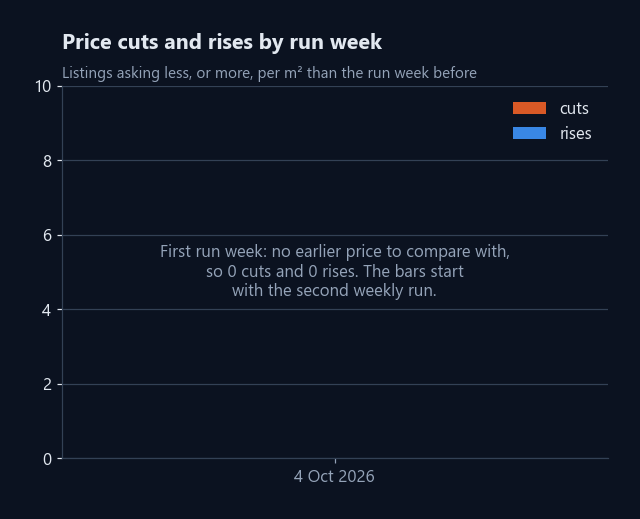

In [13]:
fig, ax = plt.subplots(figsize=(6.4, 4.4))
x = range(len(per_week))
ax.bar([i - 0.15 for i in x], per_week.cuts, width=0.3, color=SITE_COLOURS[1], label="cuts")
ax.bar([i + 0.15 for i in x], per_week.rises, width=0.3, color=SITE_COLOURS[0], label="rises")
ax.set_xticks(list(x), [f"{w.day} {w:%b %Y}" for w in per_week.index])
ax.set_xlim(-0.8, len(per_week) - 0.2)
ax.set_ylim(0, max(10, per_week.values.max() * 1.15))
ax.yaxis.set_major_formatter(lambda v, _: f"{v:,.0f}")
ax.yaxis.grid(True, color=GRID, linewidth=0.8)
ax.set_axisbelow(True)
ax.set_title("Price cuts and rises by run week", pad=24)
ax.text(0, 1.02, "Listings asking less, or more, per m² than the run week before", transform=ax.transAxes,
        color=MUTED, fontsize=10)
ax.legend(frameon=False, loc="upper right", labelcolor=INK)
if len(per_week) == 1:
    ax.text(0.5, 0.5, f"First run week: no earlier price to compare with,\nso {numbers['price_cuts']} cuts and "
            f"{numbers['price_rises']} rises. The bars start\nwith the second weekly run.",
            transform=ax.transAxes, ha="center", va="center", color=MUTED, fontsize=11)
fig.savefig(ROOT / "docs" / "price-cuts-by-week.png")

## 9. The widest gap

Grain: one row per area (`gold.area_gap`); rank 1 is the area whose median gap is furthest from 0
in either direction. A tie for rank 1 stops the notebook, so the README never names one area of two.

In [14]:
widest = area_gap[area_gap.gap_rank == 1]
assert len(widest) == 1, f"{len(widest)} areas share rank 1: {list(widest.area)}"
numbers.update(widest_gap_area=widest.area.iat[0], widest_gap_pct=widest.median_gap_pct.iat[0])
print(f"Widest gap: {numbers['widest_gap_area']}, {pct(numbers['widest_gap_pct'], signed=True)}% against the median of the same type in the same area")

Widest gap: 6th of October, +7.4% against the median of the same type in the same area


## 10. Quarantine

Grain: one row of `silver.quarantine` is one rejected row and reason in a run week. The share is
over every row that passed or failed the checks: `silver.price_observation` plus `silver.quarantine`.

In [15]:
quarantine = query("SELECT run_week, source, reason, count(*) AS rows FROM silver.quarantine GROUP BY 1, 2, 3 ORDER BY 1, 2, 3")
quarantined = int(quarantine.rows.sum())
assert quarantine[quarantine.run_week == latest_week].rows.sum() == run_log.rows_quarantined.sum(), \
    "silver.quarantine and silver.run_log disagree on the week's rejected rows"
numbers.update(quarantined_rows=quarantined,
               quarantine_share_pct=quarantined / (numbers["price_observations"] + quarantined) * 100,
               quarantine_by_reason={k: int(v) for k, v in quarantine.groupby("reason").rows.sum().items()})
print(f"{quarantined} rows set aside, {pct(numbers['quarantine_share_pct'])}% of "
      f"{numbers['price_observations'] + quarantined:,} rows checked")
quarantine

26 rows set aside, 0.4% of 5,808 rows checked


,run_week,source,reason,rows
0,2026-10-04,aqarmap,unknown type,13
1,2026-10-04,nawy,price missing or <= 0,11
2,2026-10-04,nawy,unknown type,1
3,2026-10-04,realestate,unit page not read,1


## 11. Run time

Grain: one Airflow DAG run. The latest successful run of `egypt_real_estate_prices`, start to end,
from the Airflow REST API (`/auth/token`, then `/api/v2/dags/.../dagRuns`). Its task tries are
listed: a retried task's time is inside the run's time, and an extract that finds the week's pages
already saved reads them from disk, so this is not how long a live read of the sites takes.

The README gives an estimate instead. Grain of the second table: one row per automated site
(realestate, propertyfinder, dubizzle, nawy), latest run week: the pages it read (`silver.run_log`
`pages_read`, summed over its areas) times the wait between two requests (`DELAY` in `tracker.py`
and `sites.py`). The four extracts run in parallel, so the estimate is the slowest site's. Retries
and the browser sites (Bayut, Aqarmap, read by hand before the run) are not in it.


In [16]:
AIRFLOW = "http://127.0.0.1:8101"
headers = {"Authorization": f"Bearer {requests.get(f'{AIRFLOW}/auth/token', timeout=30).json()['access_token']}"}
response = requests.get(f"{AIRFLOW}/api/v2/dags/egypt_real_estate_prices/dagRuns", headers=headers, timeout=30,
                        params={"state": "success", "order_by": "-end_date", "limit": 1})
response.raise_for_status()
assert response.json()["dag_runs"], "Airflow has no successful run of egypt_real_estate_prices"
run = response.json()["dag_runs"][0]
seconds = (pd.Timestamp(run["end_date"]) - pd.Timestamp(run["start_date"])).total_seconds()
numbers.update(run_id=run["dag_run_id"], run_seconds=seconds, run_minutes=seconds / 60)
print(f"{run['dag_run_id']}: {run['start_date']} to {run['end_date']}, {seconds:,.3f} seconds")
tasks = requests.get(f"{AIRFLOW}/api/v2/dags/egypt_real_estate_prices/dagRuns/{run['dag_run_id']}/taskInstances",
                     headers=headers, timeout=30).json()["task_instances"]
pd.DataFrame(tasks)[["task_id", "state", "try_number", "start_date", "end_date", "duration"]].sort_values("start_date")

manual__run_week_2026-10-04: 2026-10-05T02:29:21.777112Z to 2026-10-05T03:01:46.719840Z, 1,944.943 seconds


,task_id,state,try_number,start_date,end_date,duration
5,extract_realestate,success,2,2026-10-05T02:55:07.029344Z,2026-10-05T02:55:07.870031Z,0.840687
3,extract_propertyfinder,success,2,2026-10-05T02:55:07.029429Z,2026-10-05T02:57:56.850316Z,169.820887
4,extract_nawy,success,2,2026-10-05T02:55:07.036068Z,2026-10-05T02:59:55.116497Z,288.080429
6,extract_dubizzle,success,2,2026-10-05T02:55:07.045313Z,2026-10-05T02:58:38.310554Z,211.265241
0,load_silver,success,1,2026-10-05T02:59:56.103893Z,2026-10-05T03:01:42.225915Z,106.122022
1,build_gold,success,1,2026-10-05T03:01:42.486061Z,2026-10-05T03:01:44.851890Z,2.365829
2,report,success,1,2026-10-05T03:01:45.737291Z,2026-10-05T03:01:46.430441Z,0.693150


In [17]:
AUTOMATED = ("realestate", "propertyfinder", "dubizzle", "nawy")
delays = {name: float(re.search(r"^DELAY = ([\d.]+)", (ROOT / name).read_text(encoding="utf-8"), re.M)[1])
          for name in ("tracker.py", "sites.py")}
assert len(set(delays.values())) == 1, f"tracker.py and sites.py wait differently: {delays}"
request_seconds = delays["tracker.py"]
pages = query("SELECT source, sum(pages_read) AS pages FROM silver.run_log WHERE run_week = %s AND source = ANY(%s)"
              " GROUP BY source ORDER BY pages DESC, source", latest_week, list(AUTOMATED)).set_index("source").pages
assert sorted(pages.index) == sorted(AUTOMATED) and (pages > 0).all(), f"pages read this week: {pages.to_dict()}"
numbers.update(live_read_pages_by_site={s: int(n) for s, n in pages.items()}, live_read_request_seconds=request_seconds,
               live_read_slowest_site=pages.index[0], live_read_minutes_estimate=int(pages.iat[0]) * request_seconds / 60)
print(f"Live read estimate: {pages.iat[0]:,} pages on {pages.index[0]} x {request_seconds} s / 60 = "
      f"{numbers['live_read_minutes_estimate']:.3f} minutes")
pages.to_frame().assign(minutes=pages * request_seconds / 60)


Live read estimate: 969 pages on realestate x 2.5 s / 60 = 40.375 minutes


,pages,minutes
source,,
realestate,969,40.375000
nawy,92,3.833333
propertyfinder,49,2.041667
dubizzle,48,2.000000


## 12. The Power BI checks

Each check in `powerbi/06-checks.md` gives the numbers a report page must show and the SQL that
gives them, on the gold layer as the report reads it. This section runs that SQL as printed (read
from the file, so the two cannot drift) and keeps each value in `numbers` for the file's slots.
Where a value already has a key above, the check's SQL must agree with it. Two keys look alike and
differ: the cuts and rises of C14 count every run week (`price_cuts` counts the latest one only),
and the compounds and developers of C9 count the latest run week (`compounds_covered` counts any
week). C16 and C17 need a price change, so they hold "(Blank)" and "no rows yet" until the second
weekly run.


In [18]:
checks_md = (ROOT / "powerbi" / "06-checks.md").read_text(encoding="utf-8")
CHECK_SQL = dict(re.findall(r"\*\*(C\d+)\.\*\*.*?```sql\n(.*?)```", checks_md, re.S))
assert list(CHECK_SQL) == [f"C{i}" for i in range(1, 19)], list(CHECK_SQL)


def check_sql(name):
    return "\n".join(line for line in CHECK_SQL[name].splitlines() if not line.lstrip().startswith("--"))


def check(name):
    """The rows of each statement under a check, run as printed."""
    return [query(statement) for statement in check_sql(name).split(";") if statement.strip()]


c1 = check("C1")[0].iloc[0]
assert (int(c1.run_weeks), c1.latest_week, int(c1.prices_latest_week)) == (
    numbers["run_weeks"], latest_week, numbers["listings_compared"]), c1

c2 = check("C2")[0].iloc[0]
numbers.update({f"table_rows_{table}": int(n) for table, n in c2.items()})

c3 = check("C3")[0].iloc[0]
assert (int(c3.our_units), c3.widest_gap_area, int(c3.listings)) == (
    numbers["our_units"], numbers["widest_gap_area"], numbers["listings_compared"]), c3
assert (int(c3.listings_in_our_types), int(c3.listings_cheaper)) == (
    numbers["listings_in_our_types"], numbers["listings_cheaper_than_ours"]), c3
assert pct(c3.share_cheaper_pct) == pct(numbers["share_listings_cheaper_than_ours"]), c3
numbers.update(units_above_market_pct=float(c3.share_above_pct), units_below_market_pct=float(c3.share_below_pct))

c4 = check("C4")[0].dropna(subset=["median_gap_pct"])
numbers["area_bar_labels"] = ", ".join(f"{r['name']} {pct(r.median_gap_pct)}%" for _, r in c4.iterrows())

c5 = check("C5")[0]
bubbles = c5[(c5.listings > 0) & c5.lat.notna() & c5.lon.notna()]
assert len(bubbles) == 1 or bubbles.listings.iat[0] > bubbles.listings.iat[1], "two areas tie for the biggest bubble"
numbers.update(map_bubbles=len(bubbles), map_biggest_area=bubbles["name"].iat[0])

c6_top, c6_count = check("C6")
assert (int(c6_count.units[0]), int(c6_count.no_comparison[0])) == (numbers["our_units"], numbers["units_without_comparison"])
numbers["units_top_by_gap"] = ", ".join(f"{r.unit_code} ({pct(r.gap_pct)}%)" for _, r in c6_top.iterrows())

c7 = check("C7")[0].iloc[0]
assert int(c7.listings) == numbers["listings_by_area"]["new_cairo"], c7
assert pct(c7.share_cheaper_pct) == pct(numbers["share_cheaper_new_cairo"]), c7
numbers.update(new_cairo_our_units=int(c7.our_units), new_cairo_units_above_pct=float(c7.share_above_pct),
               new_cairo_units_below_pct=float(c7.share_below_pct), new_cairo_listings=int(c7.listings))

c8 = check("C8")[0].iloc[0]
assert (int(c8.our_units), int(c8.listings)) == (numbers["our_units"], numbers["listings_by_site"]["dubizzle"]), c8
numbers.update(dubizzle_units_above_pct=float(c8.share_above_pct),
               dubizzle_units_below_pct=float(c8.share_below_pct), dubizzle_share_cheaper_pct=float(c8.share_cheaper_pct),
               dubizzle_widest_gap_area=c8.widest_gap_area, dubizzle_listings=int(c8.listings))

c9 = check("C9")[0].iloc[0]
assert int(c9.listings) == numbers["listings_compared"], c9
numbers.update(compounds_latest_week=int(c9.compounds), developers_latest_week=int(c9.developers),
               cheapest_compound=c9.cheapest_compound, dearest_compound=c9.dearest_compound)

numbers["matrix_first_compounds"] = ", ".join(dict.fromkeys(check("C10")[0].compound))
numbers["dearest_developers"] = ", ".join(check("C11")[0].developer)
numbers["band_table_top_rows"] = ", ".join(f"{r.area} {r.unit_type} ({int(r.listings):,} listings)"
                                           for _, r in check("C12")[0].iterrows())

c13 = check("C13")[0].iloc[0]
assert int(c13.listings) == numbers["new_cairo_listings"], c13
numbers.update(new_cairo_compounds=int(c13.compounds), new_cairo_developers=int(c13.developers),
               new_cairo_cheapest_compound=c13.cheapest_compound, new_cairo_dearest_compound=c13.dearest_compound)

c14 = check("C14")[0].iloc[0]
assert (int(c14.price_changes), int(c14.listings)) == (numbers["price_changes"], numbers["listings_compared"]), c14
numbers.update(cuts_all_weeks=int(c14.cuts), rises_all_weeks=int(c14.rises),
               average_change_pct=None if pd.isna(c14.average_change_pct) else float(c14.average_change_pct))

numbers["weeks_with_changes"] = len(check("C15")[0])

c17 = check("C17")[0]
assert len(c17) == min(5, numbers["price_changes"])
numbers["deepest_cuts"] = ", ".join(f"{r.listing_id} on {r.site} ({pct(r.change_pct)}%)"
                                    for _, r in c17.iterrows()) or "no rows yet"
deepest = {"deepest_cut_old_m2": None, "deepest_cut_new_m2": None, "deepest_cut_ours_m2": None}
if len(c17):  # C16 is printed for 'dubizzle' and listing '0': run it for the deepest cut of C17
    cut = c17.iloc[0]
    source = query("SELECT source FROM gold.dim_site WHERE name = %s", cut.site).source[0]
    sql = check_sql("C16").replace("'dubizzle'", "%s").replace("'0'", "%s").strip().rstrip(";")
    c16 = query(sql, source, cut.listing_id).set_index("week_key")
    deepest = {"deepest_cut_old_m2": float(c16.price_per_m2[cut.old_week_key]),
               "deepest_cut_new_m2": float(c16.price_per_m2[cut.week_key]),
               "deepest_cut_ours_m2": None if pd.isna(c16.ours_same_type_per_m2.iat[0]) else float(c16.ours_same_type_per_m2.iat[0])}
numbers.update(deepest)

c18 = check("C18")[0].iloc[0]
assert int(c18.listings) == numbers["new_cairo_listings"], c18
numbers.update(new_cairo_price_changes=int(c18.price_changes), new_cairo_cuts=int(c18.cuts), new_cairo_rises=int(c18.rises))
print(f"18 checks run; {len(c2)} tables counted; {numbers['area_bar_labels']}")


18 checks run; 12 tables counted; 6th of October 7.4%, Sheikh Zayed 2.8%, New Capital 1.8%, North Coast -0.1%, Mostakbal City -0.6%, New Cairo -0.7%


## 13. The card's numbers

Every slot is written as `docs/notebook-slots.md` says: counts with thousands separators,
percentages to one decimal (signed for a gap), prices per m² in whole EGP, dates like 4 October 2026. A text value (an area, a phrase such as
"1 weekly run", or a list of rows for a Power BI check) is written as it is, and a value the
warehouse has not got yet is written "(Blank)", as Power BI shows it.
`numbers.json` keeps the unrounded values; the text is formatted from it.

In [19]:
def slot_text(key, values):
    value = values[key]
    if value is None:
        return "(Blank)"
    if key in ("first_run_week", "latest_run_week"):
        day = date.fromisoformat(value)
        return f"{day.day} {day:%B %Y}"
    if isinstance(value, str):
        return value
    if key == "widest_gap_pct" or key.startswith("gap_pct_"):
        return pct(value, signed=True)
    if key.endswith("_pct") or key.startswith("share_"):
        return pct(value)
    if key == "live_read_minutes_estimate" or "_m2" in key:
        return f"{half_up(value, 0):,}"
    return f"{value:,}"


s = {key: slot_text(key, numbers) for key in ("listings_compared", "sites_read", "areas_read", "compounds_covered",
                                               "developers_covered", "widest_gap_pct", "widest_gap_area",
                                               "quarantined_rows", "quarantine_share_pct")}
numbers["card_title"] = f"Our asking price per m² against {s['listings_compared']} competing listings, every week"
numbers["card_result"] = (f"{s['listings_compared']} competing listings from {s['sites_read']} sites in {s['areas_read']} "
                          f"areas read and checked, {s['compounds_covered']} compound names and {s['developers_covered']} "
                          f"developers covered; our units' widest gap is {s['widest_gap_pct']}% in {s['widest_gap_area']}, "
                          f"and {s['quarantined_rows']} rows ({s['quarantine_share_pct']}%) were set aside with their reason.")
(ROOT / "analysis" / "numbers.json").write_text(json.dumps(numbers, indent=2, ensure_ascii=False) + "\n", encoding="utf-8")
print("Title: ", numbers["card_title"])
print("Result:", numbers["card_result"])

Title:  Our asking price per m² against 5,782 competing listings, every week
Result: 5,782 competing listings from 6 sites in 6 areas read and checked, 1,157 compound names and 307 developers covered; our units' widest gap is +7.4% in 6th of October, and 26 rows (0.4%) were set aside with their reason.


## 14. Write the README, the checks and the pictures from numbers.json

Every `<!--nb:KEY-->…<!--/nb-->` slot in README.md, powerbi/06-checks.md and powerbi/08-build-checklist.md and every `<tspan id="nb-KEY">` in the two SVGs
is filled from `numbers.json`; the markers stay, so the next run refreshes them. In
`price-gap-by-area.svg` the band, the median tick and our units' dots of each area are moved to their
prices on the shared scale (the track runs from x 230 to x 690); nothing else in the file changes.

In [20]:
values = json.loads((ROOT / "analysis" / "numbers.json").read_text(encoding="utf-8"))
X0, X1 = 230, 690


def x_of(m2):
    return round(X0 + (m2 - values["scale_min_m2"]) / (values["scale_max_m2"] - values["scale_min_m2"]) * (X1 - X0), 1)


def fill(path, pattern, replace):
    text = path.read_bytes().decode("utf-8")
    found = re.findall(pattern, text)
    assert found, f"no slot in {path.name}"
    path.write_bytes(re.sub(pattern, replace, text).encode("utf-8"))
    return len(found)


written = {
    path.name: fill(path, r"<!--nb:(\w+)-->.*?<!--/nb-->", lambda m: f"<!--nb:{m[1]}-->{slot_text(m[1], values)}<!--/nb-->")
    for path in (ROOT / "README.md", ROOT / "powerbi" / "06-checks.md", ROOT / "powerbi" / "08-build-checklist.md")
}
for name in ("header.svg", "price-gap-by-area.svg"):
    written[name] = fill(ROOT / "docs" / name, r'<tspan id="nb-(\w+)">[^<]*</tspan>',
                         lambda m: f'<tspan id="nb-{m[1]}">{slot_text(m[1], values)}</tspan>')

svg_path = ROOT / "docs" / "price-gap-by-area.svg"
svg = svg_path.read_bytes().decode("utf-8")
for area_id, slot in AREA_SLOT.items():
    block = re.search(rf"  <!-- {re.escape(area_name[area_id])} -->\n.*?(?=\n\s*<!--)", svg, re.S)
    assert block, f"no strip for {area_name[area_id]} in the SVG"
    part = block[0]
    y = float(re.search(r'<line x1="[^"]*" y1="([\d.]+)" x2="[^"]*" y2="[^"]*" class="track"/>', part)[1])
    p25, p75, median = (x_of(values[f"{k}_m2_{slot}"]) for k in ("p25", "p75", "median"))
    part = re.sub(r'<rect x="[^"]*"( y="[^"]*") width="[^"]*"( height="[^"]*" rx="[^"]*" class="band"/>)',
                  rf'<rect x="{p25:g}"\1 width="{round(p75 - p25, 1):g}"\2', part)
    part = re.sub(r'<line x1="[^"]*"( y1="[^"]*") x2="[^"]*"( y2="[^"]*" class="median"/>)',
                  rf'<line x1="{median:g}"\1 x2="{median:g}"\2', part)
    part = re.sub(r'\n  <circle [^>]*class="ours"/>', "", part)
    dots = "".join(f'\n  <circle cx="{x_of(m2):g}" cy="{y:g}" r="7" class="ours"/>' for m2 in values[f"our_units_m2_{slot}"])
    part = re.sub(r'(<line [^>]*class="median"/>)', lambda m: m[1] + dots, part)
    svg = svg[:block.start()] + part + svg[block.end():]
svg_path.write_bytes(svg.encode("utf-8"))
print(written)

{'README.md': 23, '06-checks.md': 68, '08-build-checklist.md': 14, 'header.svg': 5, 'price-gap-by-area.svg': 20}


## 15. Every slot filled

Each slot is parsed back out of the files: none may still hold the placeholder `…`, and every key
must be in `numbers.json`.

In [21]:
left_empty = {}
for path in (ROOT / "README.md", ROOT / "powerbi" / "06-checks.md", ROOT / "powerbi" / "08-build-checklist.md",
             ROOT / "docs" / "header.svg", ROOT / "docs" / "price-gap-by-area.svg"):
    text = path.read_bytes().decode("utf-8")
    assert "[from the notebook]" not in text, f"{path.name} still has a value to fill"
    slots = re.findall(r"<!--nb:(\w+)-->(.*?)<!--/nb-->", text) + re.findall(r'<tspan id="nb-(\w+)">([^<]*)</tspan>', text)
    assert all(key in values for key, _ in slots)
    left_empty[path.name] = [key for key, value in slots if value in ("", "…")]
    print(f"{path.name}: {len(slots)} slots, {len(left_empty[path.name])} unfilled")
assert not any(left_empty.values()), left_empty
for name in ("listings-by-area.png", "gap-by-area.png", "price-cuts-by-week.png"):
    assert (ROOT / "docs" / name).stat().st_size > 0
conn.close()

README.md: 23 slots, 0 unfilled
06-checks.md: 68 slots, 0 unfilled
08-build-checklist.md: 14 slots, 0 unfilled
header.svg: 5 slots, 0 unfilled


price-gap-by-area.svg: 20 slots, 0 unfilled
